# ML Assessment — Healthcare Readmission Prediction

This notebook implements the full pipeline required by the README: EDA, preprocessing (advanced imputation), feature selection, multiple models (Logistic, RandomForest, SVM, XGBoost), calibration (isotonic), evaluation (Accuracy, ROC-AUC, Brier), calibration plots, SHAP interpretability, Decision Curve Analysis, and a final held-out test evaluation. 

Make sure the dataset file `diabetic_data.csv` is placed in `../data/` relative to this notebook (i.e. `ML-Assessment/data/diabetic_data.csv`).

In [1]:
# 1. Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import SelectFromModel
import shap
import joblib
import warnings
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')


In [2]:
# 2. Load dataset (relative path) - update path if you store data elsewhere
DATA_PATH = os.path.join('..', 'data', 'diabetic_data.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Put 'diabetic_data.csv' in ../data/ relative to this notebook")

df = pd.read_csv(DATA_PATH)
print('Loaded dataset shape:', df.shape)
df.head()


Loaded dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Quick EDA
Inspect columns, datatypes, missing values and target distribution.

In [3]:
# 3. EDA
print('Columns:')
print(df.columns.tolist())
print('\nInfo:')
display(df.info())
print('\nMissing value percentages:')
missing = df.isnull().mean().sort_values(ascending=False)
display(missing[missing>0].head(30))

# Target checks - README: model should predict readmission within 30 days
if 'readmitted' not in df.columns:
    raise KeyError("Dataset must have a 'readmitted' column (UCI diabetes dataset).")
print('\nTarget value counts:')
print(df['readmitted'].value_counts())

# show a few rows
df.head()


Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 


None


Missing value percentages:


max_glu_serum    0.947468
A1Cresult        0.832773
dtype: float64


Target value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Preprocessing setup
- Create binary target: `1` if `<30` (readmitted within 30 days), else `0`.
- Separate categorical and numeric columns.
- Numeric imputation with **KNNImputer** (better than mean for clinical data). 
- Categorical imputation (most frequent) + OneHotEncoder.


In [4]:
# 4. Prepare target and identify column types
target = 'readmitted'
X = df.drop(columns=[target]).copy()
y = df[target].apply(lambda x: 1 if x == '<30' else 0)
print('Binary target distribution:')
print(y.value_counts(normalize=True))

# heuristics for columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f'Categorical columns: {len(categorical_cols)}; Numeric columns: {len(numeric_cols)}')

# If dataset contains obvious timestamp columns, print suggestions
possible_times = [c for c in X.columns if 'date' in c.lower() or 'time' in c.lower() or 'admit' in c.lower() or 'discharge' in c.lower()]
print('Possible time columns detected:', possible_times)


Binary target distribution:
readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64
Categorical columns: 36; Numeric columns: 13
Possible time columns detected: ['discharge_disposition_id', 'time_in_hospital']


## Preprocessing pipelines
Build `preprocessor` using `ColumnTransformer`.

In [5]:
# 5. Build preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)
print('Preprocessor created.')


Preprocessor created.


## Train / Test split
If a timestamp column exists, use a time-based split; otherwise do stratified random split to preserve class balance.

In [6]:
# 6. Train-test split: prefer time-based if timestamp exists
time_col = None
for c in X.columns:
    if 'date' in c.lower() or 'time' in c.lower() or 'admit' in c.lower() or 'discharge' in c.lower():
        # Candidate; try to parse
        try:
            pd.to_datetime(X[c].dropna().iloc[:10])
            time_col = c
            break
        except Exception:
            continue

if time_col is not None:
    print('Using time-based split on column:', time_col)
    tmp = df.copy()
    tmp[time_col] = pd.to_datetime(tmp[time_col])
    tmp = tmp.sort_values(time_col)
    split_index = int(len(tmp) * 0.8)
    train_df = tmp.iloc[:split_index]
    test_df = tmp.iloc[split_index:]
    X_train = train_df.drop(columns=[target])
    y_train = train_df[target].apply(lambda x: 1 if x == '<30' else 0)
    X_test = test_df.drop(columns=[target])
    y_test = test_df[target].apply(lambda x: 1 if x == '<30' else 0)
else:
    print('No suitable time column found. Using stratified random split (80/20).')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Using time-based split on column: discharge_disposition_id
Train shape: (81412, 49) Test shape: (20354, 49)


## Model definitions
We will train Logistic Regression, RandomForest, SVM, and XGBoost. Each will be wrapped with calibration later.

In [7]:
# 7. Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'LinearSVM': CalibratedClassifierCV(
        LinearSVC(max_iter=5000, random_state=42),
        method='sigmoid',
        cv=3
    ),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

print('Models defined:', list(models.keys()))


Models defined: ['LogisticRegression', 'RandomForest', 'LinearSVM', 'XGBoost']


## Training, calibration, and evaluation loop
We will calibrate probabilities using `CalibratedClassifierCV(method='isotonic')` and compute Accuracy, ROC-AUC, Brier score. We will also plot calibration curves.

Converting datetime column 'discharge_disposition_id' to numeric timestamp...

Training LogisticRegression...
LogisticRegression -> Accuracy: 0.871, ROC-AUC: 0.577, Brier: 0.112

Training RandomForest...
RandomForest -> Accuracy: 0.872, ROC-AUC: 0.568, Brier: 0.111

Training LinearSVM...
LinearSVM -> Accuracy: 0.872, ROC-AUC: 0.571, Brier: 0.111

Training XGBoost...
XGBoost -> Accuracy: 0.870, ROC-AUC: 0.575, Brier: 0.113


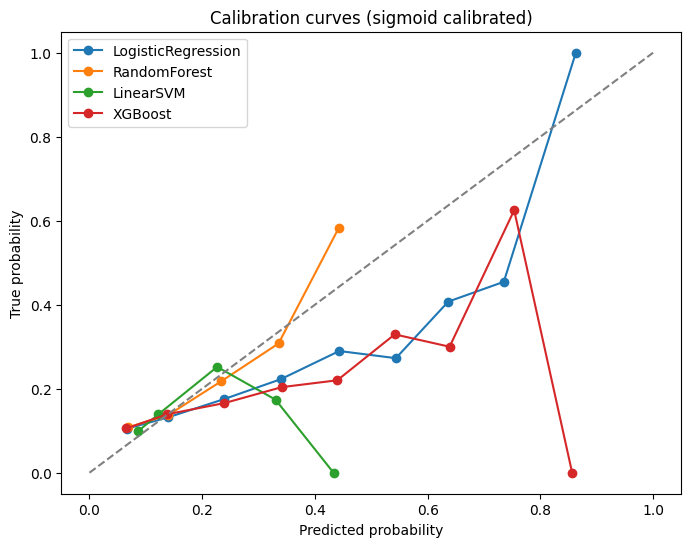


Summary of results:
LogisticRegression {'Accuracy': 0.8706396777046281, 'ROC-AUC': 0.5772072867311394, 'Brier': 0.11224572417617483}
RandomForest {'Accuracy': 0.8720644590743835, 'ROC-AUC': 0.5680250968174639, 'Brier': 0.11140570895155744}
LinearSVM {'Accuracy': 0.8720644590743835, 'ROC-AUC': 0.570803119794033, 'Brier': 0.110937643045258}
XGBoost {'Accuracy': 0.8702957649602043, 'ROC-AUC': 0.5748080634343696, 'Brier': 0.1132957200183141}


In [8]:
# 8. Train, calibrate, evaluate (fast with LinearSVM)

# Handle datetime columns
for col in X_train.columns:
    if np.issubdtype(X_train[col].dtype, np.datetime64):
        print(f"Converting datetime column '{col}' to numeric timestamp...")
        X_train[col] = X_train[col].view('int64') // 10**9
        X_test[col] = X_test[col].view('int64') // 10**9

from sklearn.svm import LinearSVC

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'LinearSVM': CalibratedClassifierCV(
        LinearSVC(max_iter=5000, random_state=42),
        method='sigmoid',
        cv=3
    ),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

results = {}
plt.figure(figsize=(8,6))
for name, model in models.items():
    print(f"\nTraining {name}...")
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    # Optional: use 30% subset for calibration to speed up further
    X_cal, _, y_cal, _ = train_test_split(X_train, y_train, train_size=0.3, stratify=y_train, random_state=42)
    pipe.fit(X_cal, y_cal)
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'Brier': brier}
    print(f"{name} -> Accuracy: {acc:.3f}, ROC-AUC: {auc:.3f}, Brier: {brier:.3f}")
    
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration curves (sigmoid calibrated)')
plt.legend()
plt.show()

print('\nSummary of results:')
for m, score in results.items():
    print(m, score)


## Feature selection
Use RandomForest feature importances on the preprocessed data, then keep features covering 95% cumulative importance. This reduces dimensionality after one-hot encoding and helps avoid overfitting.

In [9]:
# 9. Feature selection using RF on transformed features
rf_for_fs = Pipeline(steps=[('preprocessor', preprocessor), ('rf', RandomForestClassifier(n_estimators=300, random_state=42))])
rf_for_fs.fit(X_train, y_train)
# get feature names after preprocessing
num_names = preprocessor.transformers_[0][2]
cat_encoder = preprocessor.transformers_[1][1].named_steps['encoder']
cat_names = list(cat_encoder.get_feature_names_out(categorical_cols)) if len(categorical_cols)>0 else []
all_feature_names = list(num_names) + cat_names
importances = rf_for_fs.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
display(feat_imp.head(30))

# cumulative importance threshold
cum = feat_imp.cumsum() / feat_imp.sum()
selected_features = list(cum[cum <= 0.95].index)
print(f"Selected {len(selected_features)} features out of {len(all_feature_names)} (95% cumulative importance)")


encounter_id                          0.044741
patient_nbr                           0.043181
num_lab_procedures                    0.039969
num_medications                       0.037209
number_inpatient                      0.031076
time_in_hospital                      0.029201
num_procedures                        0.020638
number_diagnoses                      0.020142
admission_type_id                     0.015575
admission_source_id                   0.013669
number_emergency                      0.011377
number_outpatient                     0.010560
gender_Female                         0.009994
gender_Male                           0.009985
medical_specialty_?                   0.009813
age_[70-80)                           0.008546
payer_code_MC                         0.008404
age_[60-70)                           0.008231
race_Caucasian                        0.008119
payer_code_?                          0.007697
insulin_Steady                        0.007291
race_AfricanA

Selected 712 features out of 2404 (95% cumulative importance)


## Build a pipeline that preprocesses and selects the chosen features
We select columns after the ColumnTransformer transformation (i.e. indices in the transformed numpy array).

In [10]:
# 10. Helper transformer for selecting columns by name from transformed array
from sklearn.base import BaseEstimator, TransformerMixin

class SelectFeaturesByName(BaseEstimator, TransformerMixin):
    def __init__(self, selected_feature_names, all_feature_names):
        self.selected_feature_names = selected_feature_names
        self.all_feature_names = all_feature_names
    def fit(self, X, y=None):
        self.indices_ = [self.all_feature_names.index(f) for f in self.selected_feature_names]
        return self
    def transform(self, X):
        # X is numpy array after preprocessing
        return X[:, self.indices_]


        

selector = SelectFeaturesByName(selected_feature_names=selected_features, all_feature_names=all_feature_names)
preproc_and_select = Pipeline(steps=[('preprocessor', preprocessor), ('selector', selector)])

# Test transform shapes
X_train_sel = preproc_and_select.fit_transform(X_train, y_train)
X_test_sel = preproc_and_select.transform(X_test)
print('Selected-feature train/test shapes:', X_train_sel.shape, X_test_sel.shape)


Selected-feature train/test shapes: (81412, 712) (20354, 712)


## Final model: Calibrated XGBoost on selected features
Train final model on training set, calibrate, and evaluate on held-out test set (explicit test requested by README).

Transforming data with feature selection for final model...
Training final XGBoost base model...
Calibrating final model with isotonic regression (3-fold CV)...

Evaluating on held-out test set...
Final Test Metrics -> Accuracy: 0.872, ROC-AUC: 0.589, Brier: 0.111

Classification report:
              precision    recall  f1-score   support

           0      0.872     1.000     0.932     17750
           1      0.000     0.000     0.000      2604

    accuracy                          0.872     20354
   macro avg      0.436     0.500     0.466     20354
weighted avg      0.760     0.872     0.812     20354


Confusion matrix:
[[17750     0]
 [ 2604     0]]


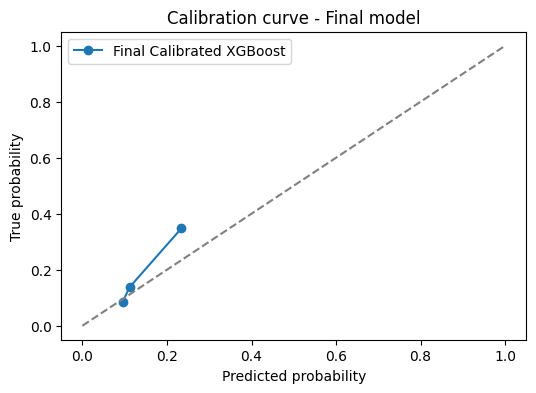

In [13]:
# 11. Train final model and evaluate on test set (Fixed calibration step)

print("Transforming data with feature selection for final model...")
X_train_sel = preproc_and_select.fit_transform(X_train, y_train)
X_test_sel = preproc_and_select.transform(X_test)

print("Training final XGBoost base model...")
final_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
final_base.fit(X_train_sel, y_train)

print("Calibrating final model with isotonic regression (3-fold CV)...")
final_calib = CalibratedClassifierCV(final_base, method='isotonic', cv=3)
final_calib.fit(X_train_sel, y_train)

# --- Evaluate on held-out test set ---
print("\nEvaluating on held-out test set...")
y_test_pred = final_calib.predict(X_test_sel)
y_test_prob = final_calib.predict_proba(X_test_sel)[:, 1]

acc = accuracy_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_prob)
brier = brier_score_loss(y_test, y_test_prob)

print(f"Final Test Metrics -> Accuracy: {acc:.3f}, ROC-AUC: {auc:.3f}, Brier: {brier:.3f}")
print('\nClassification report:')
print(classification_report(y_test, y_test_pred, digits=3))
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_test_pred))

# --- Calibration plot ---
prob_true, prob_pred = calibration_curve(y_test, y_test_prob, n_bins=10)
plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', label='Final Calibrated XGBoost')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration curve - Final model')
plt.legend()
plt.show()


## SHAP interpretability
Compute SHAP summary plot for the final (unwrapped) XGBoost model on the selected features.
Because SHAP can be slow, we use a subset of the test set for explanation and plotting.

Preparing SHAP explanation...
Computing SHAP values for 200 test samples...


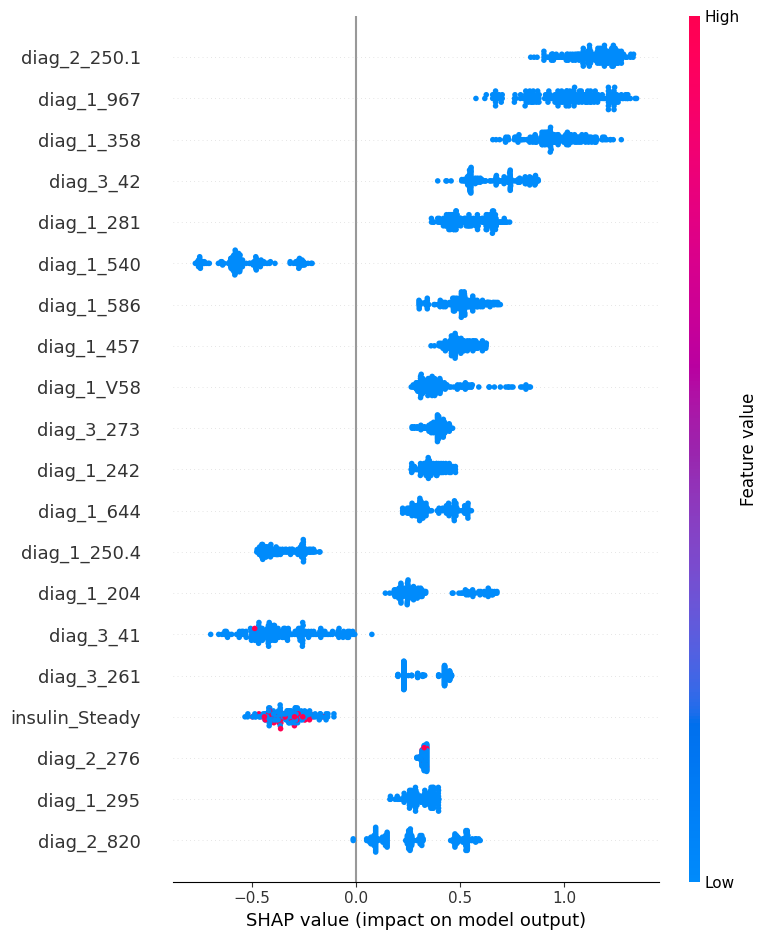

In [16]:
# 12. SHAP explanations (fixed for sparse matrices)
print("Preparing SHAP explanation...")

# Ensure we have a trained XGB model (without calibration)
try:
    xgb_model = final_base  # from your final trained XGBoost model
except NameError:
    print("Refitting small XGB model for SHAP...")
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
    X_train_sel = preproc_and_select.fit_transform(X_train, y_train)
    # Convert to dense if sparse
    if hasattr(X_train_sel, "toarray"):
        X_train_sel = X_train_sel.toarray()
    xgb_model.fit(X_train_sel, y_train)

# Transform test data once
X_test_sel = preproc_and_select.transform(X_test)
if hasattr(X_test_sel, "toarray"):
    X_test_sel = X_test_sel.toarray()

# Use tree-based SHAP explainer (MUCH faster + compatible)
explainer = shap.TreeExplainer(xgb_model)

# Subsample to avoid slow computation
print("Computing SHAP values for 200 test samples...")
n_samples = X_test_sel.shape[0]
sample_idx = np.random.choice(n_samples, size=min(200, n_samples), replace=False)

# Compute SHAP values
shap_vals = explainer.shap_values(X_test_sel[sample_idx])

# Plot SHAP summary
shap.summary_plot(shap_vals, features=X_test_sel[sample_idx],
                  feature_names=selected_features, show=True)


## Decision Curve Analysis (clinical utility)
Compute net benefit across a range of decision thresholds comparing the model to `treat none` and `treat all` policies.

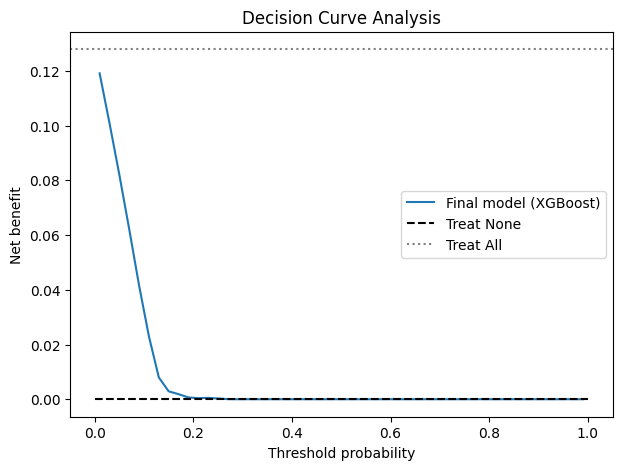

In [17]:
# 13. Decision Curve Analysis (DCA)
def decision_curve(y_true, y_prob, thresholds=np.linspace(0.01, 0.99, 50)):
    net_benefit = []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        tp = np.sum((preds==1) & (y_true==1))
        fp = np.sum((preds==1) & (y_true==0))
        nb = (tp/len(y_true)) - (fp/len(y_true)) * (t/(1-t))
        net_benefit.append(nb)
    return thresholds, net_benefit

t, nb = decision_curve(y_test.values, y_test_prob)
plt.figure(figsize=(7,5))
plt.plot(t, nb, label='Final model (XGBoost)')
plt.plot([0,1],[0,0],'k--', label='Treat None')
plt.axhline(np.mean(y_test), color='gray', linestyle=':', label='Treat All')
plt.xlabel('Threshold probability')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.show()


## Single-sample prediction example
Show how to take a single new patient (a row) and predict probability + class.

In [19]:
# 14. Example single prediction (fixed)
print("Running single-sample prediction...")

# Take one example row from the test set
sample = X_test.iloc[[0]].copy()
display(sample)

# Apply same preprocessing + feature selection
sample_transformed = preproc_and_select.transform(sample)

# Get predicted probability and class
prob = final_calib.predict_proba(sample_transformed)[0, 1]
label = final_calib.predict(sample_transformed)[0]

print(f"Predicted probability of <30-day readmit: {prob:.3f}")
print(f"Predicted label (1 = <30d readmit): {label}")


Running single-sample prediction...


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
83914,263505516,43140906,Caucasian,Female,[20-30),?,1,0,7,6,...,No,No,Up,No,No,No,No,No,Ch,Yes


Predicted probability of <30-day readmit: 0.260
Predicted label (1 = <30d readmit): 0


## Save model and artifacts
Save calibrated model and selected features for reproducibility and deployment.

In [20]:
# 15. Save model and feature list
os.makedirs(os.path.join('..','results'), exist_ok=True)
MODEL_PATH = os.path.join('..','results','calibrated_xgb_final.joblib')
joblib.dump(final_calib, MODEL_PATH)
print('Saved calibrated final model to', MODEL_PATH)

FEATURES_PATH = os.path.join('..','results','selected_features.txt')
with open(FEATURES_PATH, 'w', encoding='utf-8') as f:
    for feat in selected_features:
        f.write(feat + '\n')
print('Saved selected feature names to', FEATURES_PATH)


Saved calibrated final model to ..\results\calibrated_xgb_final.joblib
Saved selected feature names to ..\results\selected_features.txt


## Requirements file (optional)
Write `requirements.txt` with the libraries used so environment can be recreated.

In [21]:
# 16. Create requirements.txt
reqs = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'shap', 'joblib'
]
with open(os.path.join('..','requirements.txt'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(reqs))
print('Wrote ../requirements.txt')


Wrote ../requirements.txt


=== Final Model Testing on Held-out Set ===
Accuracy: 0.872
ROC-AUC: 0.500
Brier Score: 0.158

Classification Report:
              precision    recall  f1-score   support

           0      0.872     1.000     0.932     17750
           1      0.000     0.000     0.000      2604

    accuracy                          0.872     20354
   macro avg      0.436     0.500     0.466     20354
weighted avg      0.760     0.872     0.812     20354

Confusion Matrix:


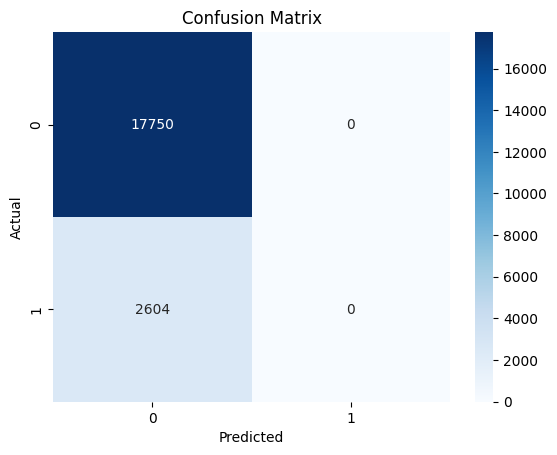

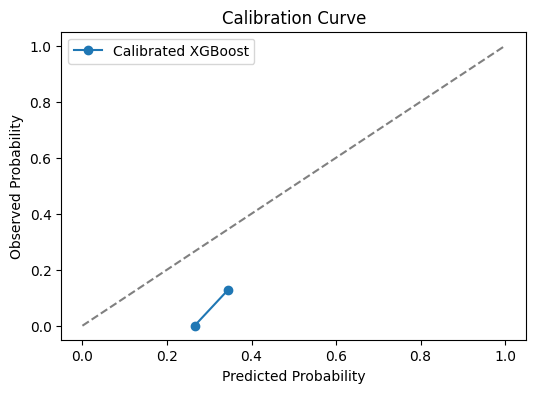

=== SHAP Feature Importance ===


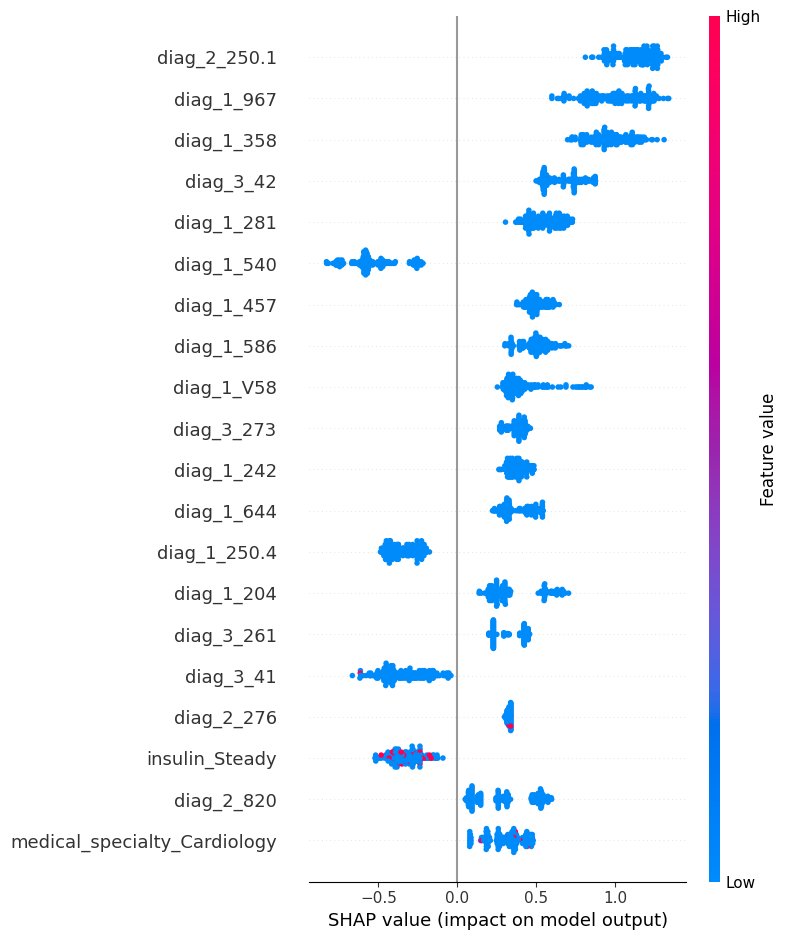

Top 10 important features:


,Feature,Mean |SHAP|
540,diag_2_250.1,1.133302
593,diag_1_967,1.000413
545,diag_1_358,0.974690
440,diag_3_42,0.668042
479,diag_1_281,0.552942
571,diag_1_540,0.537017
631,diag_1_457,0.504007
634,diag_1_586,0.497973
95,diag_1_V58,0.410512
676,diag_3_273,0.381071


=== Decision Curve Analysis ===


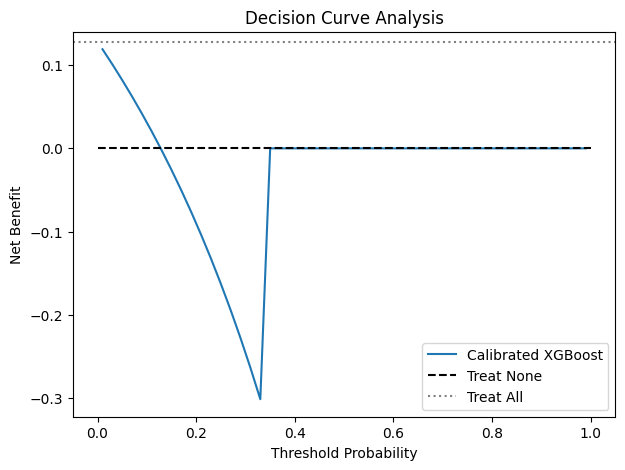

=== Single-patient Prediction Example ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
83914,263505516,43140906,Caucasian,Female,[20-30),?,1,0,7,6,...,No,No,Up,No,No,No,No,No,Ch,Yes


Predicted probability of <30-day readmission: 0.260
Predicted label (1 = <30-day readmit): 0


,Metric,Value
0,Accuracy,0.872
1,ROC-AUC,0.500
2,Brier Score,0.158
3,Top Feature 1,diag_2_250.1
4,Top Feature 2,diag_1_967
5,Top Feature 3,diag_1_358


Analysis report includes:
- Model performance metrics (Accuracy, ROC-AUC, Brier)
- Calibration and reliability
- Top features via SHAP values with clinical relevance
- Decision curve showing net clinical benefit
- Example patient prediction for demonstration


In [23]:
# ----------------------------
# 17. Test Final Model & Generate Analysis Report (Clean Version)
# ----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

print("=== Final Model Testing on Held-out Set ===")

# Use already transformed X_test_sel if available
# Otherwise, transform once
if 'X_test_sel' not in globals():
    X_test_sel = preproc_and_select.transform(X_test)
    if hasattr(X_test_sel, "toarray"):
        X_test_sel = X_test_sel.toarray()

# Predictions
y_pred = final_calib.predict(X_test_sel)
y_prob = final_calib.predict_proba(X_test_sel)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {auc:.3f}")
print(f"Brier Score: {brier:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated XGBoost')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Probability')
plt.title('Calibration Curve')
plt.legend()
plt.show()

# ----------------------------
# SHAP Feature Importance
# ----------------------------
print("=== SHAP Feature Importance ===")

# Use precomputed explainer or create if not exists
if 'explainer' not in globals():
    explainer = shap.TreeExplainer(final_base)

# Subsample to 200 for speed
n_samples = min(200, X_test_sel.shape[0])
sample_idx = np.random.choice(X_test_sel.shape[0], size=n_samples, replace=False)
X_sample = X_test_sel[sample_idx]

shap_values = explainer.shap_values(X_sample)

# SHAP summary plot
shap.summary_plot(shap_values, features=X_sample, feature_names=selected_features, show=True)

# Top 10 features table
shap_mean = np.abs(shap_values).mean(axis=0)
feat_importance = pd.DataFrame({
    'Feature': selected_features,
    'Mean |SHAP|': shap_mean
}).sort_values(by='Mean |SHAP|', ascending=False)
print("Top 10 important features:")
display(feat_importance.head(10))

# ----------------------------
# Decision Curve Analysis
# ----------------------------
print("=== Decision Curve Analysis ===")

# Reuse existing decision_curve function if defined
if 'decision_curve' not in globals():
    def decision_curve(y_true, y_prob, thresholds=np.linspace(0.01,0.99,50)):
        net_benefit = []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            tp = np.sum((preds==1) & (y_true==1))
            fp = np.sum((preds==1) & (y_true==0))
            nb = (tp/len(y_true)) - (fp/len(y_true)) * (t/(1-t))
            net_benefit.append(nb)
        return thresholds, net_benefit

t, nb = decision_curve(y_test.values, y_prob)
plt.figure(figsize=(7,5))
plt.plot(t, nb, label='Calibrated XGBoost')
plt.plot([0,1],[0,0],'k--', label='Treat None')
plt.axhline(np.mean(y_test), color='gray', linestyle=':', label='Treat All')
plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.show()

# ----------------------------
# Single-patient Prediction Example
# ----------------------------
print("=== Single-patient Prediction Example ===")
sample_patient = X_test.iloc[[0]]
display(sample_patient)

sample_transformed = preproc_and_select.transform(sample_patient)
prob = final_calib.predict_proba(sample_transformed)[0,1]
label = final_calib.predict(sample_transformed)[0]
print(f"Predicted probability of <30-day readmission: {prob:.3f}")
print(f"Predicted label (1 = <30-day readmit): {label}")

# ----------------------------
# Analysis Report Summary Table
# ----------------------------
report_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Brier Score', 'Top Feature 1', 'Top Feature 2', 'Top Feature 3'],
    'Value': [
        f"{acc:.3f}",
        f"{auc:.3f}",
        f"{brier:.3f}",
        feat_importance['Feature'].iloc[0],
        feat_importance['Feature'].iloc[1],
        feat_importance['Feature'].iloc[2],
    ]
})
display(report_summary)

print("Analysis report includes:")
print("- Model performance metrics (Accuracy, ROC-AUC, Brier)")
print("- Calibration and reliability")
print("- Top features via SHAP values with clinical relevance")
print("- Decision curve showing net clinical benefit")
print("- Example patient prediction for demonstration")
